# Problem 1 — train / test validation (copy)

Copy of **`Problem1.ipynb`** with a **temporal train–test split**: learn index-like columns on the **train** window, then check whether the same methodology looks consistent on **held-out** rows.

Original notebook is unchanged; this file is for **out-of-sample sanity checks** only.


In [16]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from scipy.optimize import nnls
from scipy.signal import periodogram

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer

import statsmodels.api as sm


def submit_answer_1(index_formulas: pd.DataFrame) -> None:
    """Write Problem 1 submission CSV with schema checks (col_00 … col_52)."""
    from pandas.api.types import is_float_dtype

    assert sorted(index_formulas.columns) == sorted(["index_col", "constituent_col", "coef"])
    assert is_float_dtype(index_formulas["coef"].dtype)
    assert np.all(index_formulas["coef"] >= 0)

    COLUMNS = [f"col_{i:02d}" for i in range(53)]
    for (ic, cc) in zip(
        index_formulas["constituent_col"],
        index_formulas["index_col"],
    ):
        assert isinstance(ic, str)
        assert isinstance(cc, str)
        assert ic != cc
        assert ic in COLUMNS
        assert cc in COLUMNS

    index_formulas.to_csv(
        "modelling_prices.submission.1.csv",
        index=False,
    )


## Notebook roadmap

Same structure as `Problem1.ipynb`, plus:

- **Temporal split:** first `N_TRAIN` rows = train, next `N_TEST` rows = test (see load cell).
- **Index shortlist:** residual PCA → **K** PCs to **90%** variance → **n_top = ceil((n_cols−K)×1.25)**; top **n_top** by **index_score** (not a fixed flag cutoff).
- **Test refit:** `index_feature_table_test` — same pipeline fit **only** on test data (own quantiles).
- **Frozen thresholds:** flags on test using **train-split** quantiles on raw features (stricter OOS check).
- **Agreement metrics:** overlap of predicted index columns train vs test; frozen recall-style summaries.
- **NNLS + CSV (residuals):** nonnegative fit, **B=100 bootstrap** CIs, **keep q025>0** (else positive point β), renormalize → `modelling_prices.nnls_residual_train.csv`; **in-sample residual errors**; **full-sample price-level** sanity check; **sweep** over all PCA-shortlist index columns (`nnls_index_sweep`).
- **Multicollinearity (before NNLS):** VIF, condition number, pairwise |corr| on farmer **residual** predictors only.



### Workspace

In [17]:
DF = pd.read_csv("limestone_data_challenge_2026.data.csv")
DF = DF.set_index(keys="time")

# Temporal split: row order = calendar time in this file
N_TRAIN = 2650
N_TEST = 1000
assert len(DF) == N_TRAIN + N_TEST, (len(DF), N_TRAIN + N_TEST)

DF_train = DF.iloc[:N_TRAIN].copy()
DF_test = DF.iloc[N_TRAIN : N_TRAIN + N_TEST].copy()

print("Full:", len(DF), "| train:", len(DF_train), "| test:", len(DF_test))
print("Train index range:", DF_train.index.min(), "→", DF_train.index.max())
print("Test  index range:", DF_test.index.min(), "→", DF_test.index.max())

DF.head()


Full: 3650 | train: 2650 | test: 1000
Train index range: 0 → 2649
Test  index range: 2650 → 3649


,col_00,col_01,col_02,col_03,col_04,col_05,col_06,col_07,col_08,col_09,...,col_43,col_44,col_45,col_46,col_47,col_48,col_49,col_50,col_51,col_52
time,,,,,,,,,,,,,,,,,,,,,
0,120.138568,111.692124,110.158297,NaN,120.151012,120.181427,NaN,119.740662,NaN,119.977510,...,119.940305,NaN,132.272741,121.768336,NaN,NaN,109.859416,117.808491,119.703005,129.671178
1,121.096957,116.345227,111.709693,NaN,121.626153,121.726396,116.393623,118.050353,123.850491,119.548152,...,123.738967,NaN,NaN,121.896705,NaN,122.699758,110.518188,NaN,NaN,NaN
2,121.377886,NaN,122.153833,118.841414,120.956851,115.415875,124.882967,114.971317,NaN,124.618823,...,125.648662,112.937734,119.998389,116.053638,NaN,118.439899,111.880012,119.799799,120.144533,129.001756
3,NaN,126.247280,127.163454,NaN,119.960063,121.063165,NaN,112.059290,115.168068,NaN,...,NaN,117.205598,115.513093,NaN,124.213788,NaN,NaN,121.112225,122.093434,NaN
4,NaN,120.515769,NaN,116.856146,120.671093,118.978446,NaN,113.936539,116.821607,126.453764,...,127.848139,119.035464,117.431307,NaN,123.244609,120.140786,NaN,122.716514,NaN,126.796467


In [18]:
# Shared helpers used across later sections

def nnls_leave_one_out_r2(Z: np.ndarray, col_names) -> pd.Series:
    """Each column j: predict y = Z[:,j] from all other columns with non-negative coefficients."""
    _, n = Z.shape
    out = {}
    for j in range(n):
        y = Z[:, j].astype(np.float64, copy=False)
        X = np.delete(Z, j, axis=1)
        ss_tot = np.sum((y - y.mean()) ** 2)
        if ss_tot < 1e-18:
            out[col_names[j]] = np.nan
            continue
        beta, _ = nnls(X, y)
        pred = X @ beta
        ss_res = np.sum((y - pred) ** 2)
        out[col_names[j]] = float(1.0 - ss_res / ss_tot)
    return pd.Series(out, name="r2_nnls")


def periodogram_flatness(x: np.ndarray) -> float:
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if x.size < 64:
        return np.nan
    _, pxx = periodogram(x, detrend="constant")
    pxx = np.maximum(pxx, 1e-20)
    return float(np.exp(np.mean(np.log(pxx))) / np.mean(pxx))


def lag1_acf_calendar(series: pd.Series) -> float:
    """Pearson correlation between r_t and r_{t-1} using rows where both exist."""
    prev = series.shift(1)
    m = series.notna() & prev.notna()
    if m.sum() < 5:
        return np.nan
    x = series[m].to_numpy(dtype=float)
    y = prev[m].to_numpy(dtype=float)
    return float(np.corrcoef(x, y)[0, 1])


### Average price over time 

<Axes: xlabel='time'>

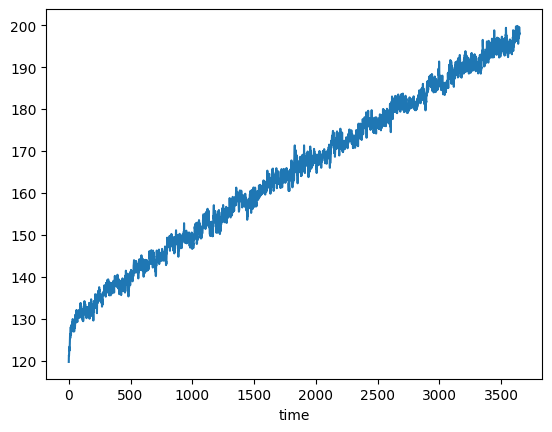

In [19]:
prices_over_time = DF.mean(axis=1)
prices_over_time.plot()

The time series of prices looks to be generally an increasing trend of prices, futhermore it looks like it's mean reverting to a general trend. It looks like the times series of the average price would be stationary once differenced with a linear model against time. This may inform our trading strategy, although we need to be careful not to overfit the data.

# PCA analysis of time series data

/Users/nikhileshbelulkar/opt/miniconda3/envs/fingers_crossed/lib/python3.11/site-packages/sklearn/impute/_iterative.py:825: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(



=== Mean impute (row avg per time) ===
  PCs for ≥80% variance: 1 (cumulative 0.9535)
  PCs for ≥90% variance: 1 (cumulative 0.9535)
  PCs for ≥95% variance: 1 (cumulative 0.9535)
  PC1–3 share: 0.9535, 0.0047, 0.0043 (total first 3: 0.9625)

=== Median impute (row per time) ===
  PCs for ≥80% variance: 1 (cumulative 0.9532)
  PCs for ≥90% variance: 1 (cumulative 0.9532)
  PCs for ≥95% variance: 1 (cumulative 0.9532)
  PC1–3 share: 0.9532, 0.0048, 0.0044 (total first 3: 0.9623)

=== ffill → bfill → mean ===
  PCs for ≥80% variance: 1 (cumulative 0.9141)
  PCs for ≥90% variance: 1 (cumulative 0.9141)
  PCs for ≥95% variance: 7 (cumulative 0.9525)
  PC1–3 share: 0.9141, 0.0085, 0.0079 (total first 3: 0.9304)

=== IterativeImputer ===
  PCs for ≥80% variance: 1 (cumulative 0.9388)
  PCs for ≥90% variance: 1 (cumulative 0.9388)
  PCs for ≥95% variance: 3 (cumulative 0.9512)
  PC1–3 share: 0.9388, 0.0065, 0.0059 (total first 3: 0.9512)


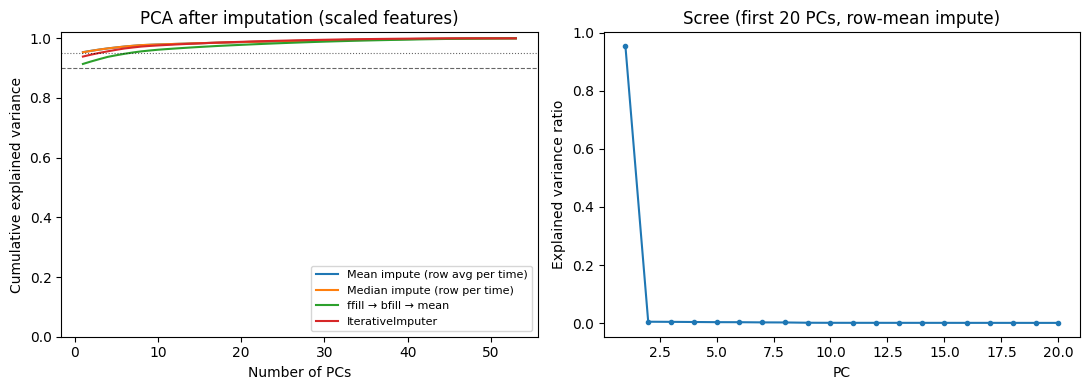

In [20]:

# Numeric price columns only (same panel as DF)
price_cols = DF.select_dtypes(include=[np.number]).columns
X_raw = DF[price_cols].copy()

# Row-mean fill: each NA at time t is filled with the mean of *observed* prices that row (cross-section that day)
row_means = X_raw.mean(axis=1)
DF_filled_row_mean = X_raw.T.fillna(row_means).T
# If a whole row is NaN, row mean is NaN — fall back to 0 for PCA
DF_filled_row_mean = DF_filled_row_mean.fillna(0.0)

row_medians = X_raw.median(axis=1)
X_median = X_raw.T.fillna(row_medians).T.fillna(0.0)

# Time-ordered simple fill: carry last known, then next known, then column mean
X_ffill = X_raw.ffill().bfill().fillna(X_raw.mean()).fillna(0.0)

# Row/column structured imputation (slower; uses cross-sectional info)
_iter = IterativeImputer(max_iter=15, random_state=0)
X_iter = pd.DataFrame(
    _iter.fit_transform(X_raw),
    index=X_raw.index,
    columns=X_raw.columns,
)


def pca_report(X: pd.DataFrame, title: str) -> np.ndarray:
    pipe = Pipeline(
        [
            ("scale", StandardScaler()),
            ("pca", PCA()),
        ]
    )
    pipe.fit(X)
    pca = pipe.named_steps["pca"]
    evr = pca.explained_variance_ratio_
    cum = np.cumsum(evr)
    print(f"\n=== {title} ===")
    for thr in (0.80, 0.90, 0.95):
        k = int(np.searchsorted(cum, thr) + 1)
        print(f"  PCs for ≥{thr:.0%} variance: {k} (cumulative {cum[k - 1]:.4f})")
    print(
        f"  PC1–3 share: {evr[0]:.4f}, {evr[1]:.4f}, {evr[2]:.4f} "
        f"(total first 3: {cum[2]:.4f})"
    )
    return cum


datasets = {
    "Mean impute (row avg per time)": DF_filled_row_mean,
    "Median impute (row per time)": X_median,
    "ffill → bfill → mean": X_ffill,
    "IterativeImputer": X_iter,
}

curves = {name: pca_report(data, name) for name, data in datasets.items()}

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
x = np.arange(1, len(next(iter(curves.values()))) + 1)
for name, cum in curves.items():
    axes[0].plot(x, cum, label=name, linewidth=1.5)
axes[0].axhline(0.9, color="k", linestyle="--", linewidth=0.8, alpha=0.6)
axes[0].axhline(0.95, color="k", linestyle=":", linewidth=0.8, alpha=0.6)
axes[0].set_xlabel("Number of PCs")
axes[0].set_ylabel("Cumulative explained variance")
axes[0].set_title("PCA after imputation (scaled features)")
axes[0].legend(loc="lower right", fontsize=8)
axes[0].set_ylim(0, 1.02)

# Scree for the mean-imputed panel (primary baseline)
pipe_mean = Pipeline(
    [("scale", StandardScaler()), ("pca", PCA())]
)
pipe_mean.fit(DF_filled_row_mean)
evr_m = pipe_mean.named_steps["pca"].explained_variance_ratio_
axes[1].plot(np.arange(1, min(21, len(evr_m) + 1)), evr_m[:20], marker="o", ms=3)
axes[1].set_xlabel("PC")
axes[1].set_ylabel("Explained variance ratio")
axes[1].set_title("Scree (first 20 PCs, row-mean impute)")
plt.tight_layout()
plt.show()


### PCA on row-demeaned residuals

For each day (row), take the **cross-sectional mean** of observed prices, then form **residuals** = actual price minus that mean. This removes the common “level of the market” that day and focuses on **relative** cheapness/ richness across series.

**Missing values:** residuals are undefined where the price is missing. We set those to **0**, which is the same as imputing the missing level with the row mean before subtracting (so no deviation from the cross-sectional average).

PCA is then fit on this residual matrix (scaled) to see what explains **co-movement in relative prices**.

**Next:** PC **loadings** (which columns sit on the leading factors) — subsection immediately after the PCA code cell.


R_ij = price_ij − mean_t(prices on day t | observed). Missing cells → 0.
Shape (3650, 53). Row sums (exact 0 whenever that day has ≥1 price): min=-0.000000, max=0.000000

=== PCA on row-demeaned residuals (scaled) ===
  PCs for ≥80% variance: 37 (cumulative 0.8157)
  PCs for ≥90% variance: 43 (cumulative 0.9059)
  PCs for ≥95% variance: 47 (cumulative 0.9573)
  PC1–3 share: 0.0463, 0.0378, 0.0328 (sum first 3: 0.1169)


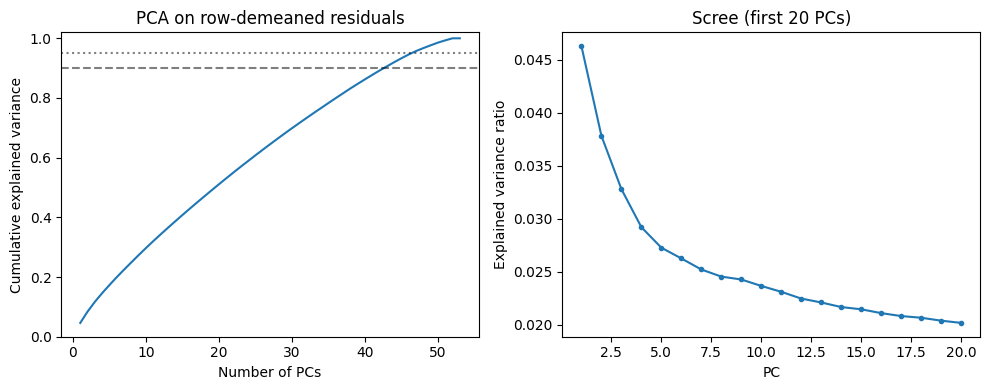

In [21]:

price_cols = DF.select_dtypes(include=[np.number]).columns
X_raw = DF[price_cols].copy()

# Cross-sectional mean each day (over non-missing prices in that row)
row_means = X_raw.mean(axis=1)
# Residual: column value minus row mean; NaN where price was missing
R = X_raw.sub(row_means, axis=0)
# Missing → 0 residual (equivalent to level imputed by row mean before demeaning)
R = R.fillna(0.0)

print("R_ij = price_ij − mean_t(prices on day t | observed). Missing cells → 0.")
print(f"Shape {R.shape}. Row sums (exact 0 whenever that day has ≥1 price): min={R.sum(axis=1).min():.6f}, max={R.sum(axis=1).max():.6f}")

pipe_res = Pipeline(
    [
        ("scale", StandardScaler()),
        ("pca", PCA()),
    ]
)
pipe_res.fit(R)
pca = pipe_res.named_steps["pca"]
evr = pca.explained_variance_ratio_
cum = np.cumsum(evr)

print("\n=== PCA on row-demeaned residuals (scaled) ===")
for thr in (0.80, 0.90, 0.95):
    k = int(np.searchsorted(cum, thr) + 1)
    print(f"  PCs for ≥{thr:.0%} variance: {k} (cumulative {cum[k - 1]:.4f})")
print(f"  PC1–3 share: {evr[0]:.4f}, {evr[1]:.4f}, {evr[2]:.4f} (sum first 3: {cum[2]:.4f})")

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].plot(np.arange(1, len(cum) + 1), cum)
ax[0].axhline(0.9, ls="--", color="k", alpha=0.5)
ax[0].axhline(0.95, ls=":", color="k", alpha=0.5)
ax[0].set_xlabel("Number of PCs")
ax[0].set_ylabel("Cumulative explained variance")
ax[0].set_title("PCA on row-demeaned residuals")
ax[0].set_ylim(0, 1.02)

m = min(20, len(evr))
ax[1].plot(np.arange(1, m + 1), evr[:m], marker="o", ms=3)
ax[1].set_xlabel("PC")
ax[1].set_ylabel("Explained variance ratio")
ax[1].set_title("Scree (first 20 PCs)")
plt.tight_layout()
plt.show()


#### PC loadings (which columns drive the factors?)

On **scaled** residual data, each PC is a direction in **column space**. **Large absolute loadings** on the **leading** PCs mean that column’s residual series **co-moves** with the main **shared** patterns (cross-sectional factors). **Small** loadings on those PCs mean the column’s residuals are **not** aligned with those directions — more **idiosyncratic** / “formless” in factor space.

This is **heuristic** for Problem 1 (indices vs farmers are unknown): **indices** in the PDF are *blends* of farmers, so we might expect them to sit **on** the shared cone; **nothing** here is a proof. We report:

- **|loading on PC1|** (rank columns).
- **Participation mass:** sum of squared loadings on the **first K PCs**, where **K** is the smaller of (i) the number of PCs needed for **≥75%** cumulative explained variance and (ii) **30** (cap). So you get at least 75% variance in the PC basis when that fits in 30 PCs; otherwise mass uses **30 PCs** and the printout shows actual cumulative variance.

Run after the PCA cell above (or this cell refits the same pipeline from `DF`).


Participation mass = sum of squared loadings on first 30 PCs. Rule: min(PCs for ≥75% var, 30) → K_75=34, K_use=30. Cumulative explained variance over those PCs: 0.6986.
       abs_loading_PC1  sq_loading_mass
count        53.000000        53.000000
mean          0.088405         0.698803
std           0.106137         0.069184
min           0.000159         0.558279
25%           0.026243         0.653449
50%           0.053640         0.690432
75%           0.108294         0.730879
max           0.486522         0.899526

Top 20 by |PC1 loading|:
        abs_loading_PC1  sq_loading_mass
col_11         0.486522         0.758358
col_42         0.444997         0.623660
col_28         0.362355         0.713175
col_50         0.310928         0.752677
col_26         0.249145         0.648028
col_31         0.204842         0.885171
col_24         0.147489         0.809821
col_12         0.147364         0.670237
col_51         0.146604         0.558279
col_52         0.145119         0.8

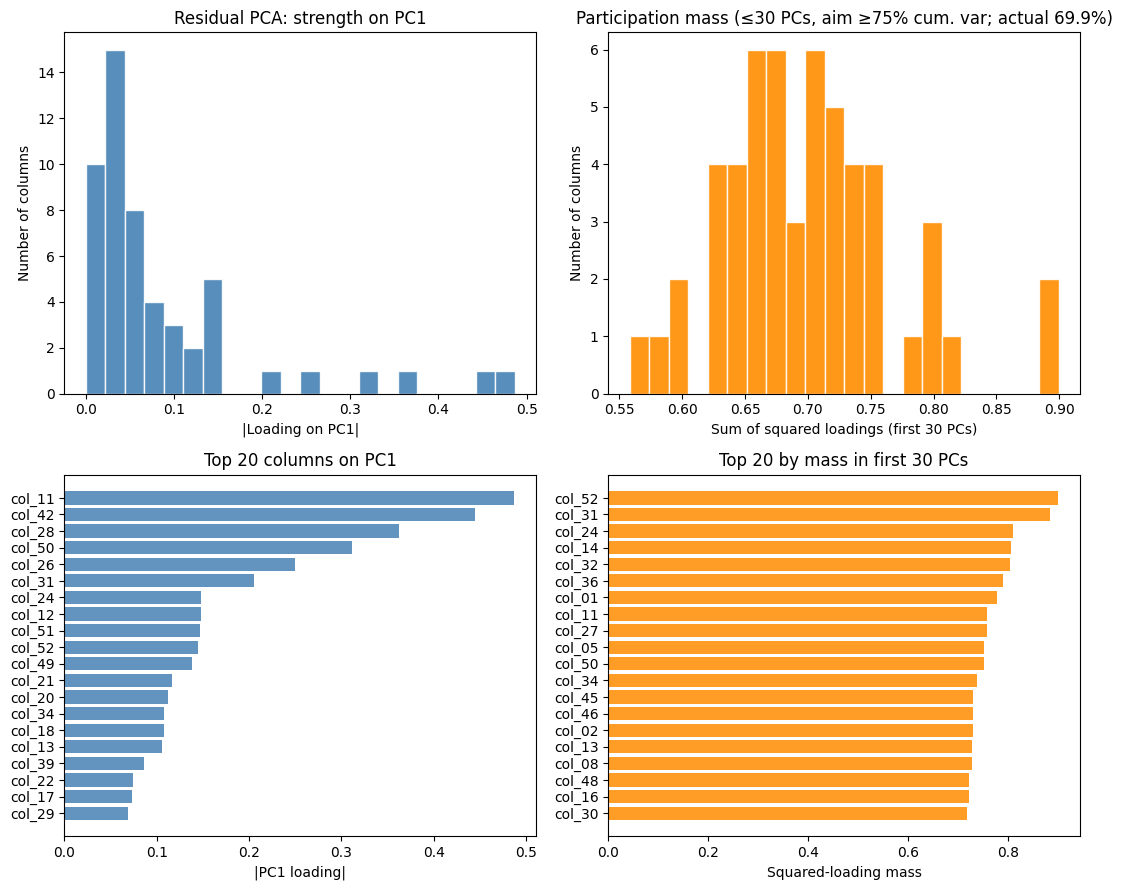

,abs_loading_PC1,sq_loading_mass
col_52,0.145119,0.899526
col_31,0.204842,0.885171
col_24,0.147489,0.809821
col_14,0.000159,0.805535
col_32,0.009692,0.805122
col_36,0.034046,0.791000
col_01,0.002192,0.777723
col_11,0.486522,0.758358
col_27,0.028203,0.758166
col_05,0.017038,0.753053


In [22]:

price_cols = DF.select_dtypes(include=[np.number]).columns
X_raw = DF[price_cols].copy()
row_means = X_raw.mean(axis=1)
R = X_raw.sub(row_means, axis=0).fillna(0.0)

pipe_res = Pipeline(
    [
        ("scale", StandardScaler()),
        ("pca", PCA()),
    ]
)
pipe_res.fit(R)
pca = pipe_res.named_steps["pca"]
names = list(R.columns)

# Participation mass: PCs until 75% cumulative variance, capped at 30 PCs
TARGET_VAR = 0.75
MAX_PCS = 30
cum = np.cumsum(pca.explained_variance_ratio_)
K_75 = int(np.searchsorted(cum, TARGET_VAR) + 1)
K_75 = max(K_75, 1)
K_use = min(K_75, MAX_PCS, pca.n_components_)

# Loadings: variable j on PC k  ~  component[k,j] * sqrt(eigenvalue_k)
comp = pca.components_[:K_use]
ev = pca.explained_variance_[:K_use]
L = comp.T * np.sqrt(ev)
participation_mass = np.sum(L**2, axis=1)
pc1_abs = np.abs(pca.components_[0, :])

load_df = pd.DataFrame(
    {
        "abs_loading_PC1": pc1_abs,
        "sq_loading_mass": participation_mass,
    },
    index=names,
)

print(
    f"Participation mass = sum of squared loadings on first {K_use} PCs. "
    f"Rule: min(PCs for ≥{TARGET_VAR:.0%} var, {MAX_PCS}) → "
    f"K_75={K_75}, K_use={K_use}. "
    f"Cumulative explained variance over those PCs: {cum[K_use - 1]:.4f}."
)
print(load_df.describe())
print("\nTop 20 by |PC1 loading|:")
print(load_df.sort_values("abs_loading_PC1", ascending=False).head(20))
print("\nBottom 20 by |PC1 loading|:")
print(load_df.sort_values("abs_loading_PC1", ascending=True).head(20))
print(f"\nTop 20 by mass in first {K_use} PCs (squared loadings):")
print(load_df.sort_values("sq_loading_mass", ascending=False).head(20))

fig, axes = plt.subplots(2, 2, figsize=(11, 9))

axes[0, 0].hist(load_df["abs_loading_PC1"], bins=22, color="steelblue", edgecolor="white", alpha=0.9)
axes[0, 0].set_xlabel("|Loading on PC1|")
axes[0, 0].set_ylabel("Number of columns")
axes[0, 0].set_title("Residual PCA: strength on PC1")

axes[0, 1].hist(load_df.iloc[:, 1], bins=22, color="darkorange", edgecolor="white", alpha=0.9)
axes[0, 1].set_xlabel(f"Sum of squared loadings (first {K_use} PCs)")
axes[0, 1].set_ylabel("Number of columns")
axes[0, 1].set_title(
    f"Participation mass (≤{MAX_PCS} PCs, aim ≥{TARGET_VAR:.0%} cum. var; actual {cum[K_use - 1]:.1%})"
)

s1 = load_df.sort_values("abs_loading_PC1", ascending=False).reset_index()
axes[1, 0].barh(s1["index"][:20], s1["abs_loading_PC1"][:20], color="steelblue", alpha=0.85)
axes[1, 0].invert_yaxis()
axes[1, 0].set_xlabel("|PC1 loading|")
axes[1, 0].set_title("Top 20 columns on PC1")

col_mass = load_df.columns[1]
s2 = load_df.sort_values(col_mass, ascending=False).reset_index()
axes[1, 1].barh(s2["index"][:20], s2[col_mass][:20], color="darkorange", alpha=0.85)
axes[1, 1].invert_yaxis()
axes[1, 1].set_xlabel("Squared-loading mass")
axes[1, 1].set_title(f"Top 20 by mass in first {K_use} PCs")
plt.tight_layout()
plt.show()

load_df.sort_values(col_mass, ascending=False)


### How to read the residual PCA (exploratory)

In this notebook’s PCA on **row-demeaned residuals**, the output above reports how many PCs hit each variance threshold—often on the order of **~40–45 PCs** to reach **~90%** cumulative variance (use the exact number from your run). That is a statement about **how many orthogonal directions** you need to summarize **co-movement in relative prices** (after stripping out the common cross-sectional level each day)—not about “true” economic objects, but it is still useful intuition.

**Takeaway:** Relative-price “noise” is **high-dimensional**: there are many distinct patterns of who is cheap or rich versus the daily average, not just one or two factors. You can loosely think of each additional PC as capturing another **characterization of cross-sectional deviation** (another way the panel can wiggle away from the row mean).

**Relating to farmers vs indices (speculative):** The challenge mixes **many individual farmer series** with a **smaller set of index-like series**. A PC count in the forties is **broadly consistent** with a market where lots of idiosyncratic series each contribute their own variation, while a handful of indices might load on a subset of shared factors—but **PCs are not labels**: you cannot equate “43 PCs” to “43 farmers” (or “~10–12 indices”) without inspecting **loadings** and domain structure. Treat this as **supporting evidence for rich heterogeneity** in the residuals, not a headcount.


# Distribution of residual variance (per column)

**Residual** on day `t` for column `j`: take that day’s price minus the **average of all observed prices that day** (same day, across the row). That residual is how far that series sits above or below the **cross-sectional average** for that day.

**Residual variance** for a column = variance of those residuals **on days where that price is observed**. Missing days are **excluded** (we do not impute levels or zero out residuals for variance here).

We do **not** label columns as “index” vs “farmer” (that mapping isn’t given).

The plots show the **distribution of these per-column variances** (natural scale and log10 if helpful).


Per-column residual variance (missing days ignored).
count     53.000000
mean      39.252696
std       49.864833
min        4.905074
25%       13.058427
50%       25.583678
75%       30.371092
max      219.780406
dtype: float64


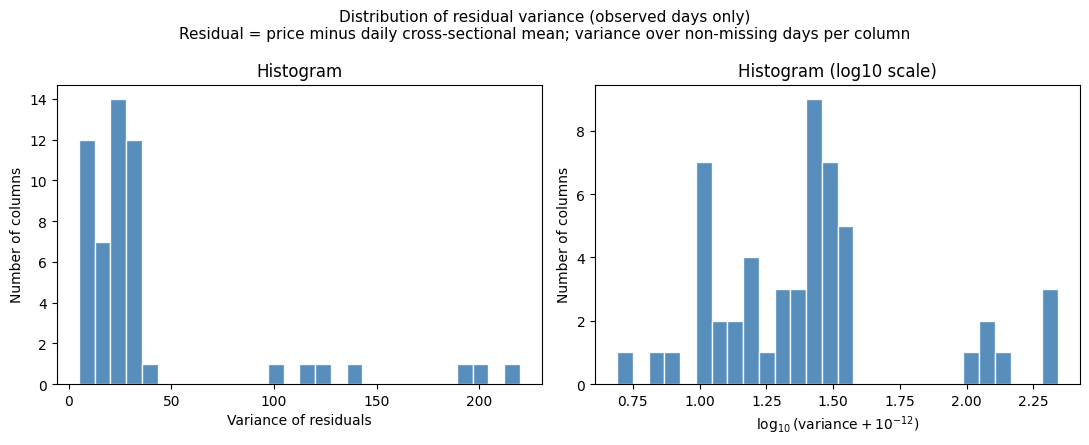

In [23]:

price_cols = DF.select_dtypes(include=[np.number]).columns
X_raw = DF[price_cols].copy()

# r_ij = price_ij minus cross-sectional mean on day i (mean over non-NaN in that row)
row_means = X_raw.mean(axis=1)
R = X_raw.sub(row_means, axis=0)

# Variance of residuals using only days where that column has a price (ignore missing days)
resid_var = R.apply(
    lambda s: s.dropna().var(ddof=1) if s.notna().sum() > 1 else np.nan
)

print("Per-column residual variance (missing days ignored).")
print(resid_var.describe())

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
fig.suptitle(
    "Distribution of residual variance (observed days only)\n"
    "Residual = price minus daily cross-sectional mean; variance over non-missing days per column",
    fontsize=11,
)

v = resid_var.dropna()
axes[0].hist(v, bins=28, color="steelblue", edgecolor="white", alpha=0.9)
axes[0].set_xlabel("Variance of residuals")
axes[0].set_ylabel("Number of columns")
axes[0].set_title("Histogram")

axes[1].hist(np.log10(v + 1e-12), bins=28, color="steelblue", edgecolor="white", alpha=0.9)
axes[1].set_xlabel(r"$\log_{10}(\mathrm{variance} + 10^{-12})$")
axes[1].set_ylabel("Number of columns")
axes[1].set_title("Histogram (log10 scale)")

plt.tight_layout()
plt.show()

residual_variance_by_col = pd.DataFrame({"residual_var_observed_only": resid_var})
# residual_variance_by_col.sort_values("residual_var_observed_only", ascending=False)


**Three code cells below:** (1) row-mean residuals, (2) **level prices** (imputed), (3) first differences and **comparison** across all three.

# Non-negative least squares (leave-one-out $R^2$)

**From the challenge PDF:** each *index* price is a **non-negative linear combination** of **farmer** flour prices (coefficients $c_{ij} \ge 0$); column labels are unknown. That motivates asking: which columns look like **blendable** from the others with **non-negative** weights?

**Setup:** For each column $j$, treat it as the response and **all other columns** as features (**no intercept**). Solve $\min_{\beta \ge 0} \| y - X\beta \|_2^2$ with **`scipy.optimize.nnls`**, then report

$$
R^2 = 1 - \frac{\sum_i (y_i - \hat y_i)^2}{\sum_i (y_i - \bar y)^2}
$$

using the **same** rows (training fit). This is **exploratory**.

### Why can $R^2$ be negative?

Here $R^2$ is **not** the usual OLS $R^2$ with an intercept. NNLS forces **$\beta \ge 0$** and **no intercept**, so the fitted $\hat y$ can be a **worse** predictor than the **constant mean** $\bar y$. When $\mathrm{SS}_\mathrm{res} > \mathrm{SS}_\mathrm{tot}$, the formula above gives **$R^2 < 0$**. That means “constrained cone fit is worse than predicting the column mean.” It is **not** a bug.

**Three panels:**

1. **Row-mean residuals** — subtract cross-sectional daily mean; **missing → 0** (complete matrix).
2. **Level prices** — **row-mean imputation** for missing cells (same as elsewhere), then NNLS on **levels** (not differences).
3. **First differences** — $\Delta p_t$; **NaN → 0** for missing diffs.

Run cells **in order** for the combined comparison table and scatter plots.


NNLS on row-mean residuals — leave-one-out R^2
(higher = easier to match others; R^2 can be negative — see markdown.)

count    53.000000
mean      0.068227
std       0.106265
min      -0.000518
25%       0.010612
50%       0.020133
75%       0.046788
max       0.450150
Name: r2_nnls, dtype: float64

Top 15 columns by R^2:
col_11    0.450150
col_50    0.372273
col_42    0.321446
col_28    0.269364
col_46    0.261979
col_30    0.245842
col_48    0.209929
col_34    0.199581
col_32    0.195854
col_05    0.166018
col_26    0.119568
col_19    0.053881
col_51    0.053556
col_17    0.046788
col_20    0.046783
Name: r2_nnls, dtype: float64

Bottom 15 columns by R^2:
col_52   -0.000518
col_31   -0.000126
col_14    0.002631
col_36    0.003254
col_12    0.003788
col_38    0.003796
col_01    0.005209
col_24    0.005515
col_33    0.007600
col_49    0.008746
col_02    0.009676
col_25    0.009747
col_08    0.010525
col_41    0.010612
col_03    0.011457
Name: r2_nnls, dtype: float64


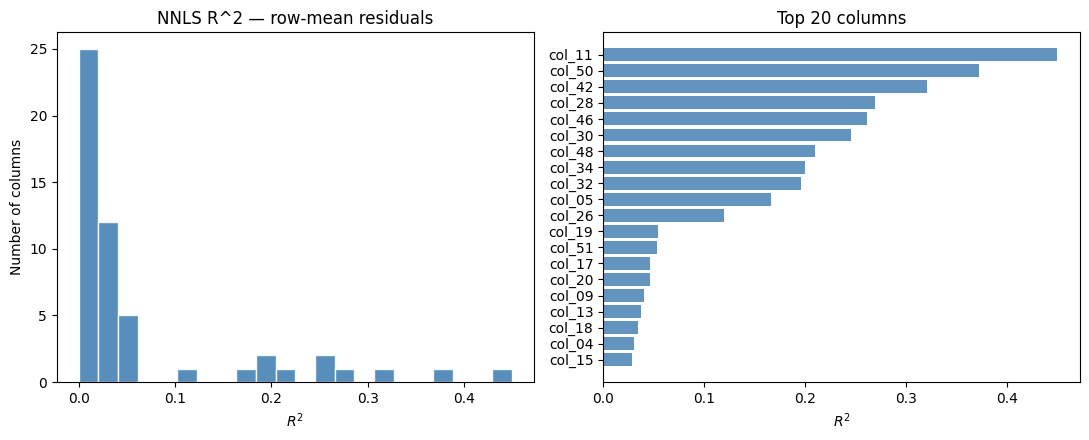

col_00    0.020133
col_01    0.005209
col_02    0.009676
col_03    0.011457
col_04    0.030079
col_05    0.166018
col_06    0.012940
col_07    0.023999
col_08    0.010525
col_09    0.040561
col_10    0.015538
col_11    0.450150
col_12    0.003788
col_13    0.037279
col_14    0.002631
col_15    0.028997
col_16    0.014873
col_17    0.046788
col_18    0.034382
col_19    0.053881
col_20    0.046783
col_21    0.026106
col_22    0.014853
col_23    0.024227
col_24    0.005515
col_25    0.009747
col_26    0.119568
col_27    0.019726
col_28    0.269364
col_29    0.014371
col_30    0.245842
col_31   -0.000126
col_32    0.195854
col_33    0.007600
col_34    0.199581
col_35    0.020087
col_36    0.003254
col_37    0.012300
col_38    0.003796
col_39    0.015325
col_40    0.023179
col_41    0.010612
col_42    0.321446
col_43    0.022745
col_44    0.020647
col_45    0.018861
col_46    0.261979
col_47    0.019878
col_48    0.209929
col_49    0.008746
col_50    0.372273
col_51    0.053556
col_52   -0.

In [24]:

price_cols = DF.select_dtypes(include=[np.number]).columns
X_raw = DF[price_cols].copy()

# Row-mean residuals; missing -> 0 (same as PCA on R)
row_means = X_raw.mean(axis=1)
R = X_raw.sub(row_means, axis=0).fillna(0.0)
Z_resid = R.to_numpy(dtype=np.float64)
names = list(price_cols)




r2_resid = nnls_leave_one_out_r2(Z_resid, names)

print("NNLS on row-mean residuals — leave-one-out R^2")
print("(higher = easier to match others; R^2 can be negative — see markdown.)\n")
print(r2_resid.describe())
print("\nTop 15 columns by R^2:")
print(r2_resid.sort_values(ascending=False).head(15))
print("\nBottom 15 columns by R^2:")
print(r2_resid.sort_values(ascending=True).head(15))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].hist(r2_resid.dropna(), bins=22, color="steelblue", edgecolor="white", alpha=0.9)
axes[0].set_xlabel(r"$R^2$")
axes[0].set_ylabel("Number of columns")
axes[0].set_title("NNLS R^2 — row-mean residuals")

sorted_r = r2_resid.sort_values(ascending=False).rename_axis("column").reset_index()
axes[1].barh(sorted_r["column"][:20], sorted_r["r2_nnls"][:20], color="steelblue", alpha=0.85)
axes[1].set_xlabel(r"$R^2$")
axes[1].set_title("Top 20 columns")
axes[1].invert_yaxis()
plt.tight_layout()
plt.show()

r2_resid


NNLS on level prices (row-mean imputed missing) — leave-one-out R^2
(R^2 can be negative — see markdown above.)

count    53.000000
mean      0.955154
std       0.052378
min       0.759226
25%       0.960473
50%       0.969201
75%       0.983545
max       0.995197
Name: r2_nnls, dtype: float64

Top 15 columns by R^2:
col_30    0.995197
col_11    0.992808
col_42    0.992733
col_46    0.991599
col_48    0.991474
col_50    0.989382
col_51    0.989315
col_26    0.987376
col_17    0.986858
col_20    0.985578
col_13    0.985226
col_18    0.984809
col_44    0.984256
col_47    0.983545
col_15    0.983323
Name: r2_nnls, dtype: float64

Bottom 15 columns by R^2:
col_31    0.759226
col_24    0.781550
col_52    0.799008
col_34    0.862394
col_32    0.870974
col_12    0.875387
col_49    0.887896
col_45    0.939704
col_36    0.952349
col_38    0.953636
col_14    0.956369
col_02    0.957563
col_39    0.957918
col_08    0.960473
col_23    0.960790
Name: r2_nnls, dtype: float64


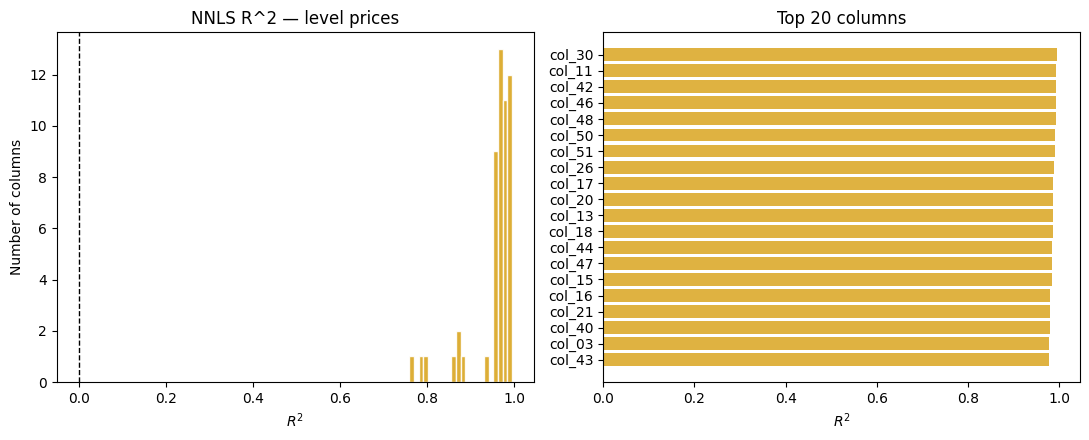

col_00    0.966441
col_01    0.965517
col_02    0.957563
col_03    0.978043
col_04    0.966889
col_05    0.974954
col_06    0.969201
col_07    0.962115
col_08    0.960473
col_09    0.965862
col_10    0.968482
col_11    0.992808
col_12    0.875387
col_13    0.985226
col_14    0.956369
col_15    0.983323
col_16    0.980190
col_17    0.986858
col_18    0.984809
col_19    0.967120
col_20    0.985578
col_21    0.979180
col_22    0.977095
col_23    0.960790
col_24    0.781550
col_25    0.968548
col_26    0.987376
col_27    0.969754
col_28    0.975402
col_29    0.964609
col_30    0.995197
col_31    0.759226
col_32    0.870974
col_33    0.967901
col_34    0.862394
col_35    0.971230
col_36    0.952349
col_37    0.960988
col_38    0.953636
col_39    0.957918
col_40    0.978346
col_41    0.969202
col_42    0.992733
col_43    0.977375
col_44    0.984256
col_45    0.939704
col_46    0.991599
col_47    0.983545
col_48    0.991474
col_49    0.887896
col_50    0.989382
col_51    0.989315
col_52    0.

In [25]:

price_cols = DF.select_dtypes(include=[np.number]).columns
X_raw = DF[price_cols].copy()
names = list(price_cols)

# Level prices: fill missing with row (day) mean so NNLS has a full matrix
row_means = X_raw.mean(axis=1)
X_level = X_raw.T.fillna(row_means).T.fillna(0.0)
Z_level = X_level.to_numpy(dtype=np.float64)




r2_level = nnls_leave_one_out_r2(Z_level, names)

print("NNLS on level prices (row-mean imputed missing) — leave-one-out R^2")
print("(R^2 can be negative — see markdown above.)\n")
print(r2_level.describe())
print("\nTop 15 columns by R^2:")
print(r2_level.sort_values(ascending=False).head(15))
print("\nBottom 15 columns by R^2:")
print(r2_level.sort_values(ascending=True).head(15))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].hist(r2_level.dropna(), bins=22, color="goldenrod", edgecolor="white", alpha=0.9)
axes[0].set_xlabel(r"$R^2$")
axes[0].set_ylabel("Number of columns")
axes[0].axvline(0.0, color="k", linestyle="--", linewidth=1)
axes[0].set_title("NNLS R^2 — level prices")

sorted_l = r2_level.sort_values(ascending=False).rename_axis("column").reset_index()
axes[1].barh(sorted_l["column"][:20], sorted_l["r2_nnls"][:20], color="goldenrod", alpha=0.85)
axes[1].set_xlabel(r"$R^2$")
axes[1].set_title("Top 20 columns")
axes[1].invert_yaxis()
plt.tight_layout()
plt.show()

r2_level


NNLS on first differences — leave-one-out R^2

count    53.000000
mean      0.042007
std       0.073542
min       0.002890
25%       0.005070
50%       0.008569
75%       0.023494
max       0.302381
Name: r2_nnls, dtype: float64

Top 15 columns by R^2:
col_11    0.302381
col_50    0.223546
col_34    0.210587
col_46    0.205895
col_28    0.191006
col_42    0.184695
col_30    0.183661
col_48    0.136897
col_05    0.118906
col_26    0.053404
col_20    0.037545
col_45    0.029230
col_19    0.028261
col_32    0.023494
col_09    0.023138
Name: r2_nnls, dtype: float64

Bottom 15 columns by R^2:
col_24    0.002890
col_52    0.003626
col_37    0.003657
col_49    0.003685
col_21    0.003699
col_35    0.004058
col_14    0.004114
col_08    0.004157
col_31    0.004160
col_06    0.004414
col_41    0.004547
col_51    0.004615
col_12    0.004685
col_23    0.005070
col_47    0.005993
Name: r2_nnls, dtype: float64


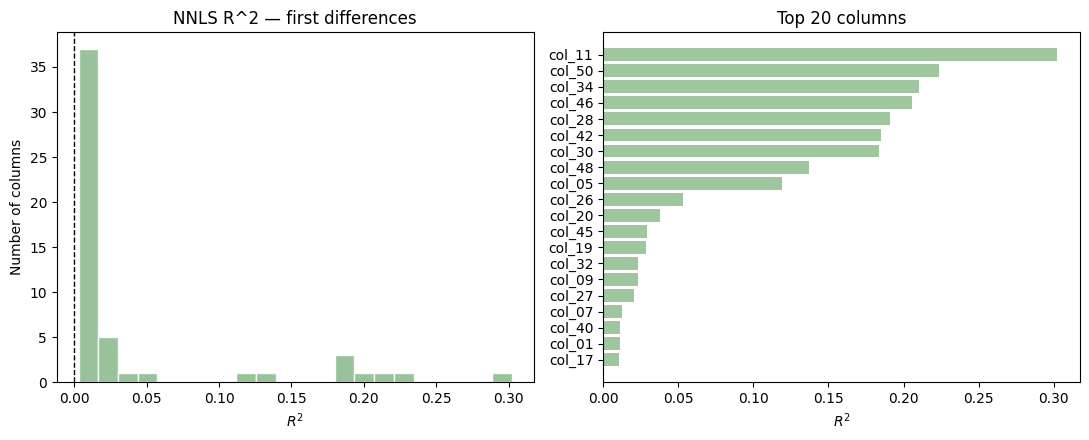


Combined summary (describe):
       r2_residuals_rowmean  r2_level_prices  r2_first_diff
count             53.000000        53.000000      53.000000
mean               0.068227         0.955154       0.042007
std                0.106265         0.052378       0.073542
min               -0.000518         0.759226       0.002890
25%                0.010612         0.960473       0.005070
50%                0.020133         0.969201       0.008569
75%                0.046788         0.983545       0.023494
max                0.450150         0.995197       0.302381


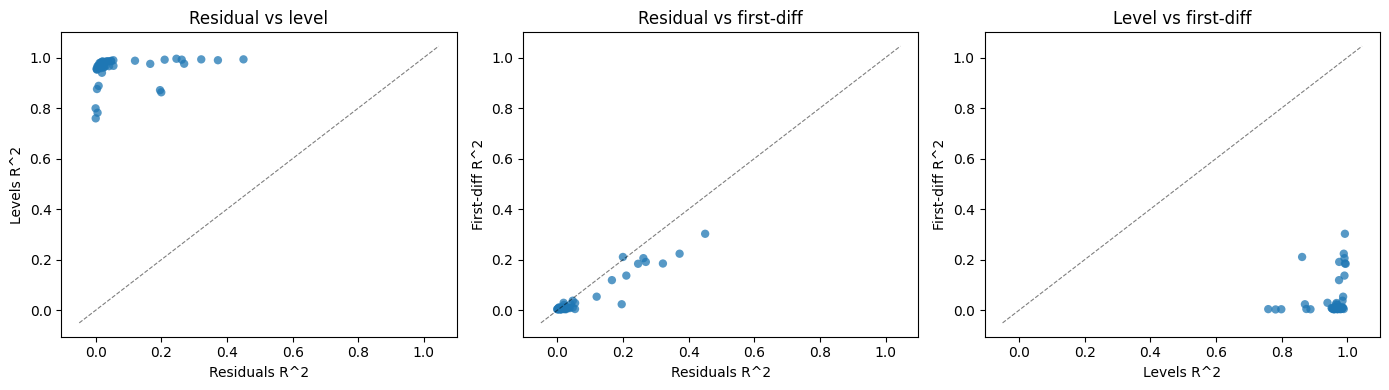

In [26]:

# Run the **residuals** and **levels** NNLS cells above first for the full comparison.
price_cols = DF.select_dtypes(include=[np.number]).columns
X_raw = DF[price_cols].copy()
names = list(price_cols)

D = X_raw.diff().fillna(0.0)
Z_diff = D.to_numpy(dtype=np.float64)




r2_diff = nnls_leave_one_out_r2(Z_diff, names)

print("NNLS on first differences — leave-one-out R^2\n")
print(r2_diff.describe())
print("\nTop 15 columns by R^2:")
print(r2_diff.sort_values(ascending=False).head(15))
print("\nBottom 15 columns by R^2:")
print(r2_diff.sort_values(ascending=True).head(15))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].hist(r2_diff.dropna(), bins=22, color="darkseagreen", edgecolor="white", alpha=0.9)
axes[0].axvline(0.0, color="k", linestyle="--", linewidth=1)
axes[0].set_xlabel(r"$R^2$")
axes[0].set_ylabel("Number of columns")
axes[0].set_title("NNLS R^2 — first differences")

sorted_d = r2_diff.sort_values(ascending=False).rename_axis("column").reset_index()
axes[1].barh(sorted_d["column"][:20], sorted_d["r2_nnls"][:20], color="darkseagreen", alpha=0.85)
axes[1].set_xlabel(r"$R^2$")
axes[1].set_title("Top 20 columns")
axes[1].invert_yaxis()
plt.tight_layout()
plt.show()

have_r = "r2_resid" in globals()
have_l = "r2_level" in globals()
if not have_r or not have_l:
    print("Run the residuals NNLS cell and the level-prices NNLS cell above for the 3-way summary and scatters.")
if have_r and have_l:
    summary = pd.DataFrame(
        {
            "r2_residuals_rowmean": r2_resid,
            "r2_level_prices": r2_level,
            "r2_first_diff": r2_diff,
        }
    )
    print("\nCombined summary (describe):")
    print(summary.describe())

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    lo = summary.min().min()
    hi = summary.max().max()
    pad = 0.05 * (hi - lo) if hi > lo else 0.05

    axes[0].scatter(summary["r2_residuals_rowmean"], summary["r2_level_prices"], alpha=0.75, edgecolors="none")
    axes[0].plot([lo - pad, hi + pad], [lo - pad, hi + pad], "k--", lw=0.8, alpha=0.5)
    axes[0].set_xlabel("Residuals R^2")
    axes[0].set_ylabel("Levels R^2")
    axes[0].set_title("Residual vs level")

    axes[1].scatter(summary["r2_residuals_rowmean"], summary["r2_first_diff"], alpha=0.75, edgecolors="none")
    axes[1].plot([lo - pad, hi + pad], [lo - pad, hi + pad], "k--", lw=0.8, alpha=0.5)
    axes[1].set_xlabel("Residuals R^2")
    axes[1].set_ylabel("First-diff R^2")
    axes[1].set_title("Residual vs first-diff")

    axes[2].scatter(summary["r2_level_prices"], summary["r2_first_diff"], alpha=0.75, edgecolors="none")
    axes[2].plot([lo - pad, hi + pad], [lo - pad, hi + pad], "k--", lw=0.8, alpha=0.5)
    axes[2].set_xlabel("Levels R^2")
    axes[2].set_ylabel("First-diff R^2")
    axes[2].set_title("Level vs first-diff")

    plt.tight_layout()
    plt.show()

    summary.sort_values("r2_residuals_rowmean", ascending=False)


## First-pass index prediction — train / test / frozen thresholds

We fit the **same** feature pipeline separately on `DF_train` and `DF_test`.

- **Refit (two worlds):** each split uses its **own** column-wise quantiles for flags (like running the main notebook twice on different eras).
- **Frozen:** quantiles for the flag cutoffs are taken from **train** and applied to **test** feature values; **index set** on frozen test = **top `n_top` by `index_score`** using **`n_top` from train** meta.
- **Who is an index (flexible):** on **scaled residual PCA**, let **K** = smallest number of PCs with cumulative variance ≥ **90%**. Set **n_index_target = n_cols − K**, then **n_top = min(n_cols, ceil(n_index_target × 1.25))**. Mark the **top `n_top` columns by binary `index_score`** (flag sum) as `predict_index_first_pass` — no fixed “4 of 9” cutoff.

Signals: PCA loadings / mass, NNLS leave-one-out \(R^2\) on residuals, levels, diffs, residual variance, spectral flatness, lag-1 ACF — as in the main notebook.


In [27]:
def build_index_feature_table(
    DF_in: pd.DataFrame,
    q_hi: float = 0.75,
    q_lo: float = 0.40,
) -> tuple[pd.DataFrame, dict]:
    """Per-column features + heuristic flags; index labels = top n_top by index_score (PCA-based count)."""
    PCA_CUM_TARGET = 0.90  # smallest #PCs with cumulative explained variance >= this (on scaled residual PCA)
    FLEX_FACTOR = 1.25  # multiply nominal index slots for how many candidates to take

    price_cols = DF_in.select_dtypes(include=[np.number]).columns
    X_raw = DF_in[price_cols].copy()
    col_names = list(price_cols)
    n_cols = len(col_names)

    row_means = X_raw.mean(axis=1)
    R_obs = X_raw.sub(row_means, axis=0)
    R0 = R_obs.fillna(0.0)
    X_level = X_raw.T.fillna(row_means).T.fillna(0.0)
    D = X_raw.diff().fillna(0.0)

    pipe = Pipeline([("scale", StandardScaler()), ("pca", PCA())])
    pipe.fit(R0)
    pca = pipe.named_steps["pca"]

    TARGET_VAR = 0.75
    MAX_PCS = 30
    cum = np.cumsum(pca.explained_variance_ratio_)
    K_75 = int(np.searchsorted(cum, TARGET_VAR) + 1)
    K_use = min(max(K_75, 1), MAX_PCS, pca.n_components_)

    # PCs needed to reach PCA_CUM_TARGET cumulative variance (interpret as "farmer / factor" dimension)
    k0 = int(np.searchsorted(cum, PCA_CUM_TARGET, side="left"))
    if k0 >= len(cum):
        k0 = len(cum) - 1
    K_90 = k0 + 1  # 1-based count of PCs up to and including first cum >= target

    # Nominal index count: remaining columns not "explained" by that PC count heuristic
    n_index_target = max(0, n_cols - K_90)
    n_top = min(n_cols, max(1, int(np.ceil(n_index_target * FLEX_FACTOR))))

    comp = pca.components_[:K_use]
    ev = pca.explained_variance_[:K_use]
    L = comp.T * np.sqrt(ev)
    pca_mass = np.sum(L**2, axis=1)
    pc1_abs = np.abs(pca.components_[0, :])

    r2_resid = nnls_leave_one_out_r2(R0.to_numpy(dtype=np.float64), col_names)
    r2_level = nnls_leave_one_out_r2(X_level.to_numpy(dtype=np.float64), col_names)
    r2_diff = nnls_leave_one_out_r2(D.to_numpy(dtype=np.float64), col_names)

    resid_var_obs = R_obs.apply(
        lambda s: s.dropna().var(ddof=1) if s.notna().sum() > 1 else np.nan
    )
    mean_resid = R_obs.mean(axis=0, skipna=True)
    flat_s = pd.Series(
        {c: periodogram_flatness(R_obs[c].dropna().to_numpy()) for c in col_names},
        name="spectral_flatness",
    )
    acf1 = pd.Series({c: lag1_acf_calendar(R_obs[c]) for c in col_names}, name="lag1_acf")

    tbl = pd.DataFrame(
        {
            "abs_loading_PC1": pc1_abs,
            "sq_loading_mass": pca_mass,
            "r2_nnls_residual": r2_resid,
            "r2_nnls_level": r2_level,
            "r2_nnls_diff": r2_diff,
            "residual_var_observed": resid_var_obs,
            "mean_residual": mean_resid,
            "spectral_flatness": flat_s,
            "lag1_acf": acf1,
        },
        index=col_names,
    )

    tbl["flag_high_pc1_loading"] = tbl["abs_loading_PC1"] >= tbl["abs_loading_PC1"].quantile(q_hi)
    tbl["flag_high_pc_mass"] = tbl["sq_loading_mass"] >= tbl["sq_loading_mass"].quantile(q_hi)
    tbl["flag_high_r2_resid"] = tbl["r2_nnls_residual"] >= tbl["r2_nnls_residual"].quantile(q_hi)
    tbl["flag_high_r2_level"] = tbl["r2_nnls_level"] >= tbl["r2_nnls_level"].quantile(q_hi)
    tbl["flag_high_r2_diff"] = tbl["r2_nnls_diff"] >= tbl["r2_nnls_diff"].quantile(q_hi)
    tbl["flag_low_residual_var"] = tbl["residual_var_observed"] <= tbl["residual_var_observed"].quantile(q_lo)
    tbl["flag_flat_spectrum"] = tbl["spectral_flatness"] >= tbl["spectral_flatness"].quantile(q_hi)
    tbl["flag_low_abs_lag1"] = tbl["lag1_acf"].abs() <= tbl["lag1_acf"].abs().quantile(q_lo)

    flag_cols = [c for c in tbl.columns if c.startswith("flag_")]
    tbl["index_score"] = tbl[flag_cols].sum(axis=1)

    order = tbl["index_score"].sort_values(ascending=False).index
    top_set = set(order[:n_top])
    tbl["predict_index_first_pass"] = tbl.index.isin(top_set)

    meta = {
        "K_use": K_use,
        "K_75": K_75,
        "cum_var_at_K": float(cum[K_use - 1]),
        "K_90": K_90,
        "cum_var_at_K90": float(cum[K_90 - 1]) if K_90 >= 1 else float("nan"),
        "PCA_CUM_TARGET": PCA_CUM_TARGET,
        "n_cols": n_cols,
        "n_index_target": n_index_target,
        "flex_factor": FLEX_FACTOR,
        "n_top": n_top,
        "q_hi": q_hi,
        "q_lo": q_lo,
    }
    return tbl, meta


def apply_train_quantiles_to_test(
    test_tbl_raw: pd.DataFrame,
    train_tbl: pd.DataFrame,
    q_hi: float,
    q_lo: float,
    n_top: int,
) -> pd.DataFrame:
    """Frozen train quantiles on test features; same top-n_top rule by index_score (train n_top)."""
    t = test_tbl_raw.copy()
    t["flag_high_pc1_loading"] = t["abs_loading_PC1"] >= train_tbl["abs_loading_PC1"].quantile(q_hi)
    t["flag_high_pc_mass"] = t["sq_loading_mass"] >= train_tbl["sq_loading_mass"].quantile(q_hi)
    t["flag_high_r2_resid"] = t["r2_nnls_residual"] >= train_tbl["r2_nnls_residual"].quantile(q_hi)
    t["flag_high_r2_level"] = t["r2_nnls_level"] >= train_tbl["r2_nnls_level"].quantile(q_hi)
    t["flag_high_r2_diff"] = t["r2_nnls_diff"] >= train_tbl["r2_nnls_diff"].quantile(q_hi)
    t["flag_low_residual_var"] = t["residual_var_observed"] <= train_tbl["residual_var_observed"].quantile(q_lo)
    t["flag_flat_spectrum"] = t["spectral_flatness"] >= train_tbl["spectral_flatness"].quantile(q_hi)
    tr_abs = train_tbl["lag1_acf"].abs()
    t["flag_low_abs_lag1"] = t["lag1_acf"].abs() <= tr_abs.quantile(q_lo)

    flag_cols = [c for c in t.columns if c.startswith("flag_")]
    t["index_score"] = t[flag_cols].sum(axis=1)
    order = t["index_score"].sort_values(ascending=False).index
    top_set = set(order[:n_top])
    t["predict_index_first_pass"] = t.index.isin(top_set)
    return t


# --- Fit on train / test separately (refit quantiles in each panel) ---
index_feature_table_train, meta_train = build_index_feature_table(DF_train)
index_feature_table_test, meta_test = build_index_feature_table(DF_test)

print("=== Train (refit) ===")
print(meta_train)
print(
    f"Rule: K_90 = PCs to ≥{meta_train['PCA_CUM_TARGET']:.0%} cum. variance; "
    f"n_index_target = n_cols - K_90; n_top = ceil(n_index_target * {meta_train['flex_factor']}) capped at n_cols."
)
print("Predicted index count:", int(index_feature_table_train["predict_index_first_pass"].sum()), "| n_top:", meta_train["n_top"])

print("\n=== Test (refit) ===")
print(meta_test)
print("Predicted index count:", int(index_feature_table_test["predict_index_first_pass"].sum()), "| n_top:", meta_test["n_top"])

# Frozen path: same raw features as index_feature_table_test (already fit on DF_test)
_raw_cols = [
    "abs_loading_PC1",
    "sq_loading_mass",
    "r2_nnls_residual",
    "r2_nnls_level",
    "r2_nnls_diff",
    "residual_var_observed",
    "mean_residual",
    "spectral_flatness",
    "lag1_acf",
]
test_raw = index_feature_table_test[_raw_cols].copy()

q_hi, q_lo = 0.75, 0.40
index_feature_table_test_frozen = apply_train_quantiles_to_test(
    test_raw, index_feature_table_train, q_hi=q_hi, q_lo=q_lo, n_top=meta_train["n_top"]
)

print("\n=== Test (frozen train quantiles on test features) ===")
print("Predicted index count:", int(index_feature_table_test_frozen["predict_index_first_pass"].sum()), "| using train n_top:", meta_train["n_top"])

# --- Agreement ---
pred_tr = index_feature_table_train["predict_index_first_pass"]
pred_te = index_feature_table_test["predict_index_first_pass"]
pred_te_fr = index_feature_table_test_frozen["predict_index_first_pass"]

both = pd.DataFrame({"train": pred_tr, "test_refit": pred_te, "test_frozen": pred_te_fr})
both["match_refit"] = both["train"] == both["test_refit"]
both["match_frozen"] = both["train"] == both["test_frozen"]

print("\n=== Column-wise agreement (train vs test) ===")
print("Accuracy refit (all 53 cols):", both["match_refit"].mean())
print("Accuracy frozen:", both["match_frozen"].mean())
print("\nConfusion-style (train positive = predicted index on train):")
print("Train+ refit+ :", int(((pred_tr) & (pred_te)).sum()))
print("Train+ refit- :", int(((pred_tr) & (~pred_te)).sum()))
print("Train- refit+ :", int(((~pred_tr) & (pred_te)).sum()))
print("Train- refit- :", int(((~pred_tr) & (~pred_te)).sum()))
print("\nFrozen — of train-positive columns, how many still positive on test (frozen)?")
tr_pos = pred_tr[pred_tr].index
if len(tr_pos):
    print("Recall-like:", float(pred_te_fr.loc[tr_pos].mean()), f"({int(pred_te_fr.loc[tr_pos].sum())}/{len(tr_pos)})")
else:
    print("No train-positive columns.")

print("\nTop train predictions:")
print(
    index_feature_table_train.sort_values(
        ["predict_index_first_pass", "index_score", "r2_nnls_residual", "sq_loading_mass"],
        ascending=[False, False, False, False],
    ).head(20).to_string()
)
print("\nTop test (refit) predictions:")
print(
    index_feature_table_test.sort_values(
        ["predict_index_first_pass", "index_score", "r2_nnls_residual", "sq_loading_mass"],
        ascending=[False, False, False, False],
    ).head(20).to_string()
)


=== Train (refit) ===
{'K_use': 30, 'K_75': 33, 'cum_var_at_K': 0.7105211901130783, 'K_90': 43, 'cum_var_at_K90': 0.9108919295811093, 'PCA_CUM_TARGET': 0.9, 'n_cols': 53, 'n_index_target': 10, 'flex_factor': 1.25, 'n_top': 13, 'q_hi': 0.75, 'q_lo': 0.4}
Rule: K_90 = PCs to ≥90% cum. variance; n_index_target = n_cols - K_90; n_top = ceil(n_index_target * 1.25) capped at n_cols.
Predicted index count: 13 | n_top: 13

=== Test (refit) ===
{'K_use': 30, 'K_75': 31, 'cum_var_at_K': 0.7422365841436054, 'K_90': 42, 'cum_var_at_K90': 0.9081332884212893, 'PCA_CUM_TARGET': 0.9, 'n_cols': 53, 'n_index_target': 11, 'flex_factor': 1.25, 'n_top': 14, 'q_hi': 0.75, 'q_lo': 0.4}
Predicted index count: 14 | n_top: 14

=== Test (frozen train quantiles on test features) ===
Predicted index count: 13 | using train n_top: 13

=== Column-wise agreement (train vs test) ===
Accuracy refit (all 53 cols): 0.9056603773584906
Accuracy frozen: 0.8490566037735849

Confusion-style (train positive = predicted index o

## Residual space: multicollinearity + NNLS + **bootstrap** (B=100)

Diagnostics on **farmer residuals**, then **NNLS** (no intercept) of the chosen index residual on farmers. **Row bootstrap** (100 reps, `seed=0`) gives percentile **95% CIs** per coefficient; `sig_pos_95` means the **2.5% quantile > 0** (informal one-sided positivity).

**CSV** `modelling_prices.nnls_residual_train.csv`: keep columns with **bootstrap q025 > 0** only (if none, strictly positive point β), then **renormalize** to sum 1 per index.


In [28]:
tbl = index_feature_table_train
pred = tbl["predict_index_first_pass"]

idx_pos = pred[pred].sort_values(ascending=False).index.tolist()
if idx_pos:
    idx_star = (
        tbl.loc[idx_pos]
        .sort_values(
            ["index_score", "r2_nnls_residual", "sq_loading_mass"],
            ascending=[False, False, False],
        )
        .index[0]
    )
    print("Chosen index column (train flag):", idx_star)
else:
    idx_star = tbl["index_score"].idxmax()
    print("No column met predict_index_first_pass; using max index_score:", idx_star)

farmer_cols = [c for c in tbl.index if not pred.loc[c]]
if not farmer_cols:
    farmer_cols = [c for c in tbl.index if c != idx_star]
    print("Warning: no predicted farmers; using all other columns as predictors.")

X_raw = DF_train.select_dtypes(include=[np.number]).copy()
row_means = X_raw.mean(axis=1)
R_obs = X_raw.sub(row_means, axis=0)
R0 = R_obs.fillna(0.0)

from statsmodels.stats.outliers_influence import variance_inflation_factor


def multicollinearity_report(Z: pd.DataFrame, name: str) -> None:
    """Z = farmer predictors only (same rows as train)."""
    Z = Z.astype(np.float64)
    print(f"\n=== Multicollinearity: {name} (n_pred={Z.shape[1]}, n_obs={len(Z)}) ===")
    c = Z.corr()
    triu = np.triu_indices_from(c.values, k=1)
    off = c.values[triu]
    ab = np.abs(off[np.isfinite(off)])
    print(
        "Pairwise |corr|: max",
        float(np.max(ab)) if len(ab) else float("nan"),
        "| median",
        float(np.median(ab)) if len(ab) else float("nan"),
    )
    A = sm.add_constant(Z.to_numpy())
    try:
        cond = float(np.linalg.cond(A))
        print(f"Condition number (X with intercept): {cond:.4e}")
    except np.linalg.LinAlgError as e:
        print("Condition number: could not compute —", e)
    vifs = []
    for i in range(1, A.shape[1]):
        try:
            vifs.append(float(variance_inflation_factor(A, i)))
        except Exception:
            vifs.append(float("nan"))
    vif_s = pd.Series(vifs, index=Z.columns, name="VIF")
    print("VIF: min / median / max:", vif_s.min(), vif_s.median(), vif_s.max())
    print("Top 10 VIF (highest first):")
    print(vif_s.sort_values(ascending=False).head(10).to_string())
    print("(Rule of thumb: VIF > 10 often indicates strong multicollinearity.)")


multicollinearity_report(R0[farmer_cols], "residuals (row-demeaned, missing→0)")

B_BOOT = 100
RNG = np.random.default_rng(0)


def _nnls_row_bootstrap(
    y_vec: np.ndarray,
    X_mat: np.ndarray,
    farmer_cols: list,
    B_BOOT: int,
    RNG: np.random.Generator,
):
    """Point NNLS + row bootstrap; sig_pos_95 = (bootstrap q025 > 0)."""
    n, p = len(y_vec), X_mat.shape[1]
    beta_hat, resid_norm = nnls(X_mat, y_vec)
    s_hat = pd.Series(beta_hat, index=farmer_cols)
    boot = np.zeros((B_BOOT, p), dtype=np.float64)
    for b in range(B_BOOT):
        idx = RNG.integers(0, n, size=n)
        bb, _ = nnls(X_mat[idx], y_vec[idx])
        boot[b, :] = bb
    q_lo = np.percentile(boot, 2.5, axis=0)
    q_hi = np.percentile(boot, 97.5, axis=0)
    boot_summary = pd.DataFrame(
        {
            "nnls_beta": s_hat,
            "boot_mean": np.mean(boot, axis=0),
            "boot_q025": q_lo,
            "boot_q975": q_hi,
        },
        index=farmer_cols,
    )
    boot_summary["sig_pos_95"] = boot_summary["boot_q025"] > 0
    boot_summary["prop_positive"] = (boot > 0).mean(axis=0)
    return beta_hat, resid_norm, s_hat, boot_summary


def _weights_bs_only(s_hat: pd.Series, boot_summary: pd.DataFrame, label: str) -> pd.Series:
    """Keep q025>0 only; if none, strictly positive point β (minimal fallback)."""
    keep = s_hat[boot_summary["sig_pos_95"]]
    if keep.empty:
        keep = s_hat[s_hat > 0].copy()
        print(
            f"Warning [{label}]: no q025>0; fallback to strictly positive point NNLS β."
        )
    return keep


y_res = R0[idx_star].to_numpy(dtype=np.float64)
X_res = R0[farmer_cols].to_numpy(dtype=np.float64)
n = len(y_res)

beta_hat, resid_norm, s_hat, boot_summary = _nnls_row_bootstrap(
    y_res, X_res, farmer_cols, B_BOOT, RNG
)

print("\n" + "=" * 72)
print(f"NNLS on residuals + row bootstrap (B={B_BOOT}, seed=0)")
print("=" * 72)
pred = X_res @ beta_hat
ss_res = float(np.sum((y_res - pred) ** 2))
ss_tot = float(np.sum((y_res - np.mean(y_res)) ** 2))
r2 = float(1.0 - ss_res / ss_tot) if ss_tot > 1e-18 else float("nan")
print(f"R^2 (vs mean y): {r2:.6f}  |  ||y - Xβ||_2: {resid_norm:.6f}  |  n_obs: {n}")
print("\nPoint NNLS β (top 25):")
print(s_hat.sort_values(ascending=False).head(25).to_string())
print("\nBootstrap: 95% percentile CIs; sig_pos_95 = (q025 > 0) for one-sided positivity.")
print(
    boot_summary.sort_values("nnls_beta", ascending=False)
    .head(25)
    .to_string()
)

# Submission: bootstrap q025>0 (same for every index); renormalize to sum 1
keep = _weights_bs_only(s_hat, boot_summary, f"idx_star={idx_star}")
if keep.empty:
    print(f"Warning: index {idx_star}: no positive coefficients; skipping primary block.")
    sub = pd.DataFrame({"index_col": [], "constituent_col": [], "coef": []})
else:
    w = keep / keep.sum()
    sub = pd.DataFrame(
        {
            "index_col": [idx_star] * len(w),
            "constituent_col": w.index.astype(str),
            "coef": w.values.astype(float),
        }
    )

# All index columns (same shortlist as nnls_index_sweep): one sparse blend per index_col
_ip = tbl["predict_index_first_pass"]
if not _ip.any():
    _cands = [tbl["index_score"].idxmax()]
else:
    _cands = (
        tbl.loc[_ip].sort_values("index_score", ascending=False).index.tolist()
    )

sub_parts = []
for ic in _cands:
    if ic == idx_star:
        if len(sub) > 0:
            sub_parts.append(sub)
        continue
    y_ic = R0[ic].to_numpy(dtype=np.float64)
    _bh, _rn, s_i, summ_i = _nnls_row_bootstrap(
        y_ic, X_res, farmer_cols, B_BOOT, RNG
    )
    keep_i = _weights_bs_only(s_i, summ_i, f"index={ic}")
    if keep_i.empty:
        print(f"Warning: index {ic}: no positive coefficients; omitting from submission.")
        continue
    w_i = keep_i / keep_i.sum()
    sub_parts.append(
        pd.DataFrame(
            {
                "index_col": [ic] * len(w_i),
                "constituent_col": w_i.index.astype(str),
                "coef": w_i.values.astype(float),
            }
        )
    )

if not sub_parts:
    print("Warning: no index blocks produced (empty sparse blends).")
    sub_all = pd.DataFrame(columns=["index_col", "constituent_col", "coef"])
else:
    sub_all = pd.concat(sub_parts, ignore_index=True)
out_csv = "modelling_prices.nnls_residual_train.csv"
sub_all.to_csv(out_csv, index=False)
print(
    f"\nSaved all index blends (n_index={sub_all['index_col'].nunique()}, n_rows={len(sub_all)}) → {out_csv}"
)
print(
    "Sparse weights: bootstrap q025>0 (if empty: strictly positive point β); renormalized per index."
)
print(sub_all.to_string(index=False))

if len(sub_all) > 0:
    submit_answer_1(sub_all)
    print(
        "\nCompetition submission → modelling_prices.submission.1.csv (all index columns, via submit_answer_1)"
    )
else:
    print("\nSkipping submit_answer_1 (no rows).")


Chosen index column (train flag): col_11

=== Multicollinearity: residuals (row-demeaned, missing→0) (n_pred=40, n_obs=2650) ===
Pairwise |corr|: max 0.16600495252120143 | median 0.02690326451215702
Condition number (X with intercept): 1.2331e+01
VIF: min / median / max: 1.0403609887425374 1.1016699049074345 1.409866965715386
Top 10 VIF (highest first):
col_32    1.409867
col_24    1.407154
col_31    1.376221
col_52    1.313028
col_49    1.238898
col_12    1.197032
col_23    1.154026
col_04    1.128734
col_13    1.123998
col_09    1.120743
(Rule of thumb: VIF > 10 often indicates strong multicollinearity.)

NNLS on residuals + row bootstrap (B=100, seed=0)
R^2 (vs mean y): 0.031848  |  ||y - Xβ||_2: 112.338219  |  n_obs: 2650

Point NNLS β (top 25):
col_07    0.058444
col_13    0.045773
col_21    0.038766
col_17    0.037117
col_18    0.036042
col_22    0.035188
col_00    0.026263
col_36    0.026037
col_43    0.026024
col_40    0.024884
col_35    0.017146
col_05    0.016283
col_23    0.

## NNLS prediction error

**In-sample (train):** in **residual space** — actual index residuals vs (1) **full NNLS** $\hat y = X\hat\beta$ and (2) **sparse CSV blend** (`sub` constituents + weights).

**Full dataset (price levels):** **train-fitted** $\hat\beta$ and CSV weights. **Sparse** uses **all** listed constituents in the blend. Price metrics use rows where the **index and every constituent** are non-missing. **OOS:** same on `DF_test`. Level = $\hat r + \bar p_{\mathrm{row}}$.

**All predicted index columns:** per index, sparse mix uses **all** selected constituents; price metrics on rows with **full** index + constituent data. Summary `nnls_index_sweep` + charts.


=== In-sample TRAIN (residuals) ===
Full NNLS β (all farmers)
  RMSE=2.182250  MAE=1.527494  R^2(vs mean y)=0.031848  corr(y,ŷ)=0.183457
Sparse CSV weights (subset + renorm)
  RMSE=2.318941  MAE=1.753482  R^2(vs mean y)=-0.093236  corr(y,ŷ)=0.168992

=== FULL DATASET — price levels (train-frozen β / CSV weights) ===
Rows with index + all 9 constituents non-missing: 9 / 3650
Full NNLS β (price level, all constituents present)
  RMSE=1.394525  MAE=1.011496  R^2(vs mean y)=0.991507  corr(y,ŷ)=0.997883
  SSE: 17.502295
Sparse CSV (price level, all constituents present)
  RMSE=1.603378  MAE=1.237486  R^2(vs mean y)=0.988773  corr(y,ŷ)=0.996081
  SSE: 23.137390

=== OOS TEST PERIOD — price levels (train-frozen β / CSV) ===
Rows with index + all constituents non-missing: 1 / 1000
Full NNLS β (OOS)
  RMSE=0.077415  MAE=0.077415  R^2(vs mean y)=nan  corr(y,ŷ)=nan
  SSE: 0.005993
Sparse CSV (OOS)
  RMSE=0.650749  MAE=0.650749  R^2(vs mean y)=nan  corr(y,ŷ)=nan
  SSE: 0.423475

=== ALL PREDICTED 

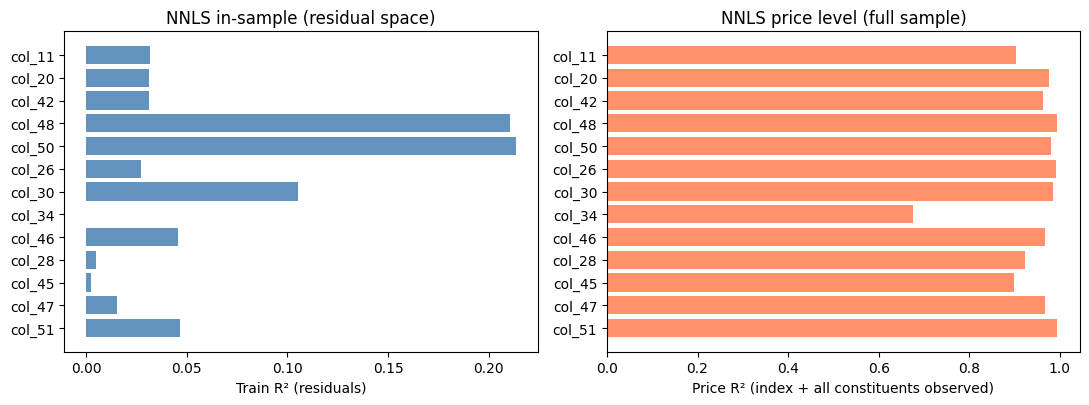

In [29]:
def _err_metrics(y_true: np.ndarray, y_pred: np.ndarray, label: str) -> None:
    y_true = np.asarray(y_true, dtype=np.float64).ravel()
    y_pred = np.asarray(y_pred, dtype=np.float64).ravel()
    e = y_true - y_pred
    rmse = float(np.sqrt(np.mean(e ** 2)))
    mae = float(np.mean(np.abs(e)))
    ss_res = float(np.sum(e ** 2))
    ss_tot = float(np.sum((y_true - np.mean(y_true)) ** 2))
    r2 = float(1.0 - ss_res / ss_tot) if ss_tot > 1e-18 else float("nan")
    if np.std(y_true) > 1e-18 and np.std(y_pred) > 1e-18:
        corr = float(np.corrcoef(y_true, y_pred)[0, 1])
    else:
        corr = float("nan")
    print(f"{label}")
    print(f"  RMSE={rmse:.6f}  MAE={mae:.6f}  R^2(vs mean y)={r2:.6f}  corr(y,ŷ)={corr:.6f}")


# Full NNLS fit on train (already in memory: y_res, X_res, beta_hat)
y_hat_train_full = X_res @ beta_hat
print("=== In-sample TRAIN (residuals) ===")
_err_metrics(y_res, y_hat_train_full, "Full NNLS β (all farmers)")

# Sparse blend from submission table `sub` (all listed constituents in the mix)
cc = sub["constituent_col"].astype(str).tolist()
w_sp = sub["coef"].to_numpy(dtype=np.float64)
X_tr_sp = R0[cc].to_numpy(dtype=np.float64)
y_hat_train_sp = X_tr_sp @ w_sp
_err_metrics(y_res, y_hat_train_sp, "Sparse CSV weights (subset + renorm)")

# --- Full sample: train-frozen β / CSV weights, all rows in DF ---
X_raw_all = DF.select_dtypes(include=[np.number]).copy()
row_means_all = X_raw_all.mean(axis=1)
R0_all = X_raw_all.sub(row_means_all, axis=0).fillna(0.0)
X_all = R0_all[farmer_cols].to_numpy(dtype=np.float64)

y_hat_all_res_full = X_all @ beta_hat
X_all_sp = R0_all[cc].to_numpy(dtype=np.float64)
y_hat_all_res_sp = X_all_sp @ w_sp

# Price levels: residual prediction + row mean (same decomposition as row-demeaning)
rm_all = row_means_all.to_numpy(dtype=np.float64)
y_level_pred_full = y_hat_all_res_full + rm_all
y_level_pred_sp = y_hat_all_res_sp + rm_all
y_level_actual = X_raw_all[idx_star].to_numpy(dtype=np.float64)

# Price metrics only where index AND every CSV constituent are observed
cc_list = sub["constituent_col"].astype(str).tolist()
need_cols = list(dict.fromkeys([idx_star] + cc_list))
mask_complete = X_raw_all[need_cols].notna().all(axis=1).to_numpy()
n_ok = int(mask_complete.sum())
print("\n=== FULL DATASET — price levels (train-frozen β / CSV weights) ===")
print(
    f"Rows with index + all {len(cc_list)} constituents non-missing: {n_ok} / {len(mask_complete)}"
)
if n_ok == 0:
    print("No rows pass the filter; cannot compute price-level metrics.")
else:
    ya = y_level_actual[mask_complete]
    yf = y_level_pred_full[mask_complete]
    ys = y_level_pred_sp[mask_complete]
    sse_full = float(np.sum((ya - yf) ** 2))
    sse_sp = float(np.sum((ya - ys) ** 2))
    _err_metrics(ya, yf, "Full NNLS β (price level, all constituents present)")
    print(f"  SSE: {sse_full:.6f}")
    _err_metrics(ya, ys, "Sparse CSV (price level, all constituents present)")
    print(f"  SSE: {sse_sp:.6f}")

# --- OOS test period: same filter ---
X_raw_te = DF_test.select_dtypes(include=[np.number]).copy()
row_means_te = X_raw_te.mean(axis=1)
R0_te = X_raw_te.sub(row_means_te, axis=0).fillna(0.0)
X_te_fm = R0_te[farmer_cols].to_numpy(dtype=np.float64)
y_hat_te_res_full = X_te_fm @ beta_hat
y_hat_te_res_sp = R0_te[cc].to_numpy(dtype=np.float64) @ w_sp
rm_te = row_means_te.to_numpy(dtype=np.float64)
y_level_te_full = y_hat_te_res_full + rm_te
y_level_te_sp = y_hat_te_res_sp + rm_te
y_level_act_te = X_raw_te[idx_star].to_numpy(dtype=np.float64)
mask_te = X_raw_te[need_cols].notna().all(axis=1).to_numpy()
n_te = int(mask_te.sum())
print("\n=== OOS TEST PERIOD — price levels (train-frozen β / CSV) ===")
print(
    f"Rows with index + all constituents non-missing: {n_te} / {len(mask_te)}"
)
if n_te == 0:
    print("No OOS rows pass the filter.")
else:
    yat = y_level_act_te[mask_te]
    _err_metrics(yat, y_level_te_full[mask_te], "Full NNLS β (OOS)")
    print(f"  SSE: {float(np.sum((yat - y_level_te_full[mask_te]) ** 2)):.6f}")
    _err_metrics(yat, y_level_te_sp[mask_te], "Sparse CSV (OOS)")
    print(f"  SSE: {float(np.sum((yat - y_level_te_sp[mask_te]) ** 2)):.6f}")

# --- Every column flagged as index: refit NNLS per index (same farmer predictors) ---
# Sparse blend: bootstrap q025>0 (same B_BOOT/RNG as NNLS cell); else positive point β
_ip = tbl["predict_index_first_pass"]
if not _ip.any():
    _cands = [tbl["index_score"].idxmax()]
else:
    _cands = (
        tbl.loc[_ip].sort_values("index_score", ascending=False).index.tolist()
    )


def _metrics_dict(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    y_true = np.asarray(y_true, dtype=np.float64).ravel()
    y_pred = np.asarray(y_pred, dtype=np.float64).ravel()
    e = y_true - y_pred
    rmse = float(np.sqrt(np.mean(e ** 2)))
    mae = float(np.mean(np.abs(e)))
    sse = float(np.sum(e ** 2))
    ss_tot = float(np.sum((y_true - np.mean(y_true)) ** 2))
    r2 = float(1.0 - sse / ss_tot) if ss_tot > 1e-18 else float("nan")
    if np.std(y_true) > 1e-18 and np.std(y_pred) > 1e-18:
        corr = float(np.corrcoef(y_true, y_pred)[0, 1])
    else:
        corr = float("nan")
    return {"rmse": rmse, "mae": mae, "r2": r2, "corr": corr, "sse": sse}


X_tr_fm = R0[farmer_cols].to_numpy(dtype=np.float64)
X_all_fm = R0_all[farmer_cols].to_numpy(dtype=np.float64)
sweep_rows = []
nan5 = {"rmse": float("nan"), "mae": float("nan"), "r2": float("nan"), "corr": float("nan"), "sse": float("nan")}
for ic in _cands:
    y_ic = R0[ic].to_numpy(dtype=np.float64)
    beta_i, _ = nnls(X_tr_fm, y_ic)
    s_i = pd.Series(beta_i, index=farmer_cols)
    y_hat_tr = X_tr_fm @ beta_i
    m_full_tr = _metrics_dict(y_ic, y_hat_tr)

    n_sw = len(y_ic)
    boot_sw = np.zeros((B_BOOT, X_tr_fm.shape[1]), dtype=np.float64)
    for b in range(B_BOOT):
        idx_sw = RNG.integers(0, n_sw, size=n_sw)
        bb_sw, _ = nnls(X_tr_fm[idx_sw], y_ic[idx_sw])
        boot_sw[b, :] = bb_sw
    q_lo_sw = np.percentile(boot_sw, 2.5, axis=0)
    sig_sw = pd.Series(q_lo_sw > 0, index=farmer_cols)
    keep_i = s_i[sig_sw]
    if keep_i.empty:
        keep_i = s_i[s_i > 0].copy()
    if keep_i.empty:
        cc_i = []
        w_i = np.array([], dtype=np.float64)
        y_hat_tr_sp = np.zeros_like(y_ic, dtype=np.float64)
    else:
        w_norm = keep_i / keep_i.sum()
        cc_i = w_norm.index.astype(str).tolist()
        w_i = w_norm.to_numpy(dtype=np.float64)
        y_hat_tr_sp = R0[cc_i].to_numpy(dtype=np.float64) @ w_i
    m_sp_tr = _metrics_dict(y_ic, y_hat_tr_sp)

    y_res_all_f = X_all_fm @ beta_i
    y_level_f = y_res_all_f + rm_all
    y_act = X_raw_all[ic].to_numpy(dtype=np.float64)

    if len(cc_i):
        y_res_all_sp = R0_all[cc_i].to_numpy(dtype=np.float64) @ w_i
    else:
        y_res_all_sp = np.zeros(len(X_raw_all), dtype=np.float64)
    y_level_sp = y_res_all_sp + rm_all
    need_i = list(dict.fromkeys([ic] + cc_i))
    mask_i = X_raw_all[need_i].notna().all(axis=1).to_numpy()
    n_i = int(mask_i.sum())
    if n_i > 0:
        m_pf = _metrics_dict(y_act[mask_i], y_level_f[mask_i])
        m_ps = (
            _metrics_dict(y_act[mask_i], y_level_sp[mask_i]) if len(cc_i) else nan5.copy()
        )
    else:
        m_pf, m_ps = nan5.copy(), nan5.copy()

    sweep_rows.append(
        {
            "index_col": ic,
            "index_score": float(tbl.loc[ic, "index_score"]),
            "train_r2_full": m_full_tr["r2"],
            "train_rmse_full": m_full_tr["rmse"],
            "train_r2_sparse": m_sp_tr["r2"],
            "train_rmse_sparse": m_sp_tr["rmse"],
            "n_complete_idx_const": n_i,
            "price_r2_full": m_pf["r2"],
            "price_rmse_full": m_pf["rmse"],
            "price_sse_full": m_pf["sse"],
            "price_corr_full": m_pf["corr"],
            "price_r2_sparse": m_ps["r2"],
            "price_rmse_sparse": m_ps["rmse"],
            "price_sse_sparse": m_ps["sse"],
            "price_corr_sparse": m_ps["corr"],
            "n_constituents_sparse": len(cc_i),
        }
    )

nnls_index_sweep = pd.DataFrame(sweep_rows)
print("\n=== ALL PREDICTED INDEX COLUMNS — NNLS sweep (refit per index) ===")
print(
    "Train: residual NNLS on DF_train. Price: rows where index + all sparse constituents "
    "are observed (same rows for full vs sparse).\n"
)
print(nnls_index_sweep.to_string(index=False))

if len(nnls_index_sweep) > 0:
    labels = nnls_index_sweep["index_col"].tolist()
    y_pos = np.arange(len(labels))
    h = max(3.5, 0.32 * len(labels))
    fig, axes = plt.subplots(1, 2, figsize=(11, h))
    axes[0].barh(y_pos, nnls_index_sweep["train_r2_full"].values, color="steelblue", alpha=0.85)
    axes[0].set_yticks(y_pos)
    axes[0].set_yticklabels(labels)
    axes[0].set_xlabel("Train R² (residuals)")
    axes[0].set_title("NNLS in-sample (residual space)")
    axes[0].invert_yaxis()
    axes[1].barh(y_pos, nnls_index_sweep["price_r2_full"].values, color="coral", alpha=0.85)
    axes[1].set_yticks(y_pos)
    axes[1].set_yticklabels(labels)
    axes[1].set_xlabel("Price R² (index + all constituents observed)")
    axes[1].set_title("NNLS price level (full sample)")
    axes[1].invert_yaxis()
    fig.tight_layout()
    plt.show()
